In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [30]:
os.path.join(os.getcwd(), os.path.join('rfm_analysis', 'rfm_analysis.csv'))

'C:\\Users\\User\\PycharmProjects\\rostelecom_hackathon\\rfm_analysis\\rfm_analysis.csv'

In [31]:
rfm_analysis = pd.read_csv(os.path.join(os.getcwd(), os.path.join('rfm_analysis', 'rfm_analysis.csv')))

In [37]:
segment_stats = rfm_analysis.groupby('rfm_segment').agg({
    'customer_id': 'count',
    'recency_days': 'mean',
    'total_orders_count': 'mean',
    'monetary_value': ['mean', 'sum'],
    'success_rate_percentage': 'mean'
}).sort_values(('customer_id', 'count'), ascending=False)

print("\nСтатистика по сегментам:")
segment_stats


Статистика по сегментам:


customer_id recency_days total_orders_count  \
                          count         mean               mean   
rfm_segment                                                       
Need attention            31022   356.194346           1.087809   
Potential loyalists       19447   272.043091           1.136679   
Recent customers          19447   369.136936           1.154985   
Loyal customers           16689    95.717838           1.041944   
Best customers             3960   123.995202           1.872222   
Big spenders               3908   529.154043           1.311157   
Promising customers        2760   187.804348           1.000000   

                    monetary_value             success_rate_percentage  
                              mean         sum                    mean  
rfm_segment                                                             
Need attention           93.565822  2902598.94               97.524338  
Potential loyalists     151.530040  2946804.68               98.009976  
Recent customers        162.866286  3167260.67               97.829999  
Loyal customers         133.635677  2230245.81               98.549943  
Best customers          374.780727  1484131.68               98.459596  
Big spenders            431.056354  1684568.23               95.752303  
Promising customers     437.991793  1208857.35               96.992754

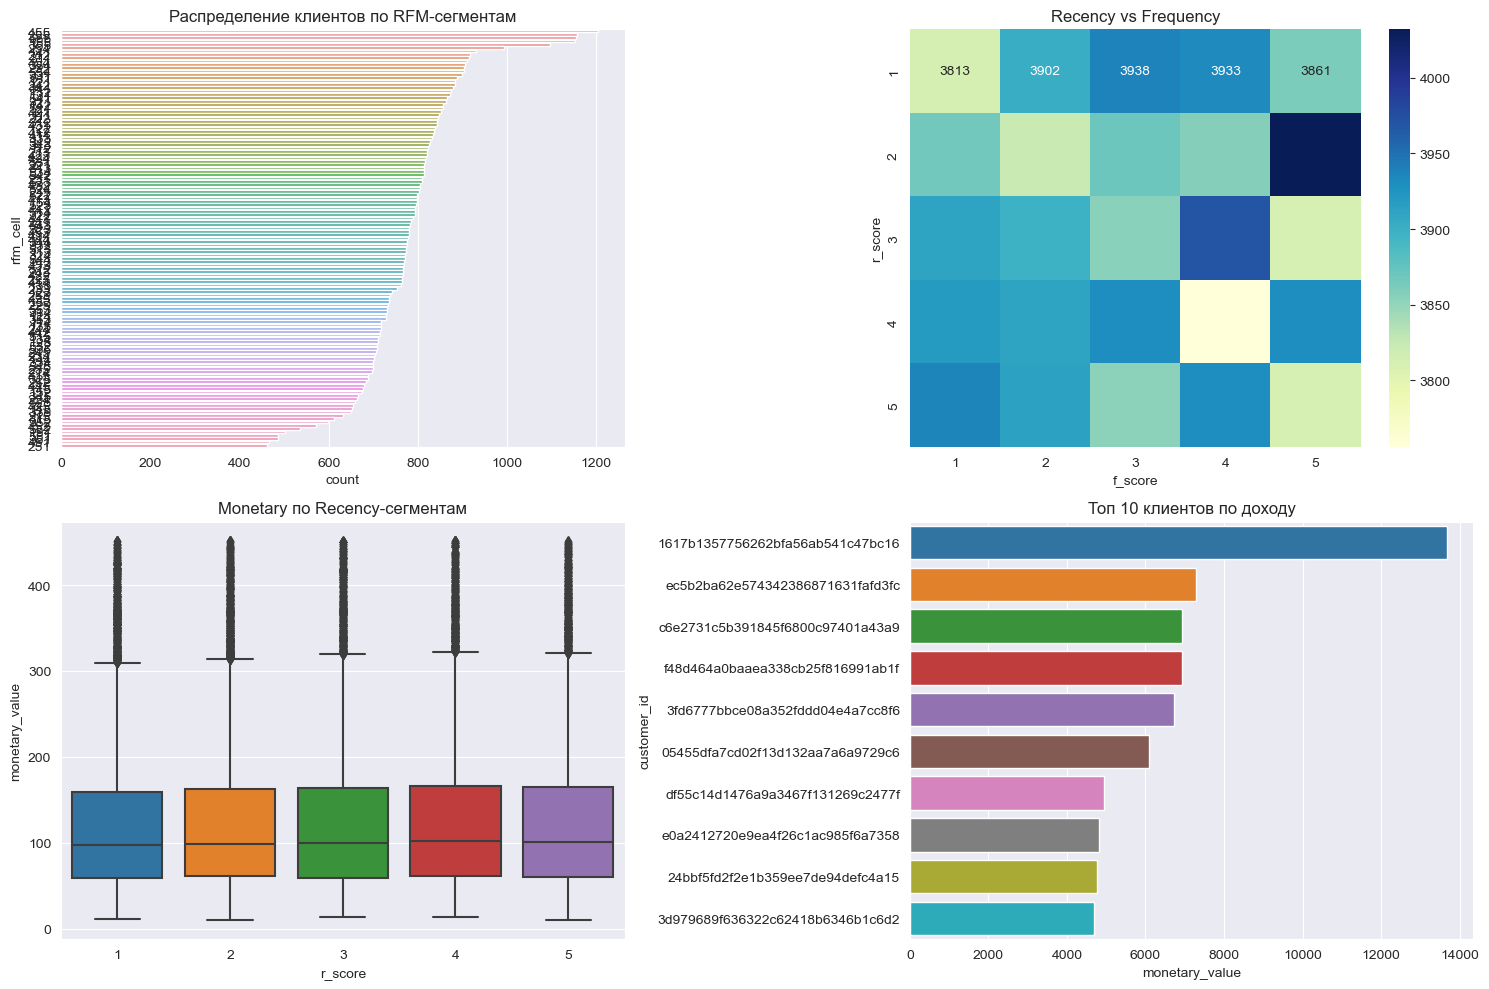

In [35]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.countplot(y='rfm_cell', data=rfm_analysis, order=rfm_analysis['rfm_cell'].value_counts().index)
plt.title('Распределение клиентов по RFM-сегментам')

plt.subplot(2, 2, 2)
rf_crosstab = pd.crosstab(rfm_analysis['r_score'], rfm_analysis['f_score'])
sns.heatmap(rf_crosstab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Recency vs Frequency')

# Boxplot Monetary по R-сегментам
plt.subplot(2, 2, 3)
sns.boxplot(x='r_score', y='monetary_value', data=rfm_analysis[rfm_analysis['monetary_value'] < rfm_analysis['monetary_value'].quantile(0.95)])
plt.title('Monetary по Recency-сегментам')

# Топ 10 клиентов по monetary
plt.subplot(2, 2, 4)
top_customers = rfm_analysis.sort_values('monetary_value', ascending=False).head(10)
sns.barplot(y='customer_id', x='monetary_value', data=top_customers)
plt.title('Топ 10 клиентов по доходу')

plt.tight_layout()
plt.show()